# 01 - MNIST Data Loading & DuckDB Storage

This notebook:
1. Reads raw MNIST IDX binary files
2. Stores them in DuckDB for fast SQL-based exploration
3. Visualizes sample digits

In [1]:
import numpy as np
import pandas as pd
import duckdb
import struct
import matplotlib.pyplot as plt
from pathlib import Path

## Load MNIST IDX Files

The IDX format stores images as raw bytes with a header containing dimensions.

In [2]:
def read_idx_images(path):
    with open(path, 'rb') as f:
        magic, n, rows, cols = struct.unpack('>IIII', f.read(16))
        return np.frombuffer(f.read(), dtype=np.uint8).reshape(n, rows * cols)

def read_idx_labels(path):
    with open(path, 'rb') as f:
        magic, n = struct.unpack('>II', f.read(8))
        return np.frombuffer(f.read(), dtype=np.uint8)

data_dir = Path('../data')
train_images = read_idx_images(data_dir / 'train-images.idx3-ubyte')
train_labels = read_idx_labels(data_dir / 'train-labels.idx1-ubyte')
test_images = read_idx_images(data_dir / 't10k-images.idx3-ubyte')
test_labels = read_idx_labels(data_dir / 't10k-labels.idx1-ubyte')

print(f'Train: {train_images.shape[0]} images, {train_images.shape[1]} pixels each')
print(f'Test:  {test_images.shape[0]} images')

Train: 60000 images, 784 pixels each
Test:  10000 images


## Store in DuckDB

We store pixel data as a flat array (784 columns for 28x28) plus the label. This lets us query and filter with SQL.

In [3]:
db_path = str(data_dir / 'mnist.duckdb')
con = duckdb.connect(db_path)

# Create train table
train_df = pd.DataFrame(train_images, columns=[f'px{i}' for i in range(784)])
train_df['label'] = train_labels
train_df['split'] = 'train'

# Create test table
test_df = pd.DataFrame(test_images, columns=[f'px{i}' for i in range(784)])
test_df['label'] = test_labels
test_df['split'] = 'test'

# Combine and write
all_df = pd.concat([train_df, test_df], ignore_index=True)
con.execute('DROP TABLE IF EXISTS mnist')
con.execute('CREATE TABLE mnist AS SELECT * FROM all_df')
print(f'Stored {len(all_df)} records in DuckDB')

Stored 70000 records in DuckDB


## Explore with SQL

In [4]:
# Label distribution
con.execute("""
    SELECT label, split, COUNT(*) as count
    FROM mnist
    GROUP BY label, split
    ORDER BY label, split
""").df()

,label,split,count
0,0,test,980
1,0,train,5923
2,1,test,1135
3,1,train,6742
4,2,test,1032
5,2,train,5958
6,3,test,1010
7,3,train,6131
8,4,test,982
9,4,train,5842


In [6]:
# Average pixel intensity per digit
con.execute("""
    SELECT label,
           ROUND(AVG(px196::INT + px197::INT + px224::INT + px225::INT), 1) as center_intensity
    FROM mnist WHERE split='train'
    GROUP BY label ORDER BY label
""").df()

,label,center_intensity
0,0,0.0
1,1,0.0
2,2,0.0
3,3,0.1
4,4,0.0
5,5,0.0
6,6,0.0
7,7,0.6
8,8,0.0
9,9,0.0


## Visualize Sample Digits

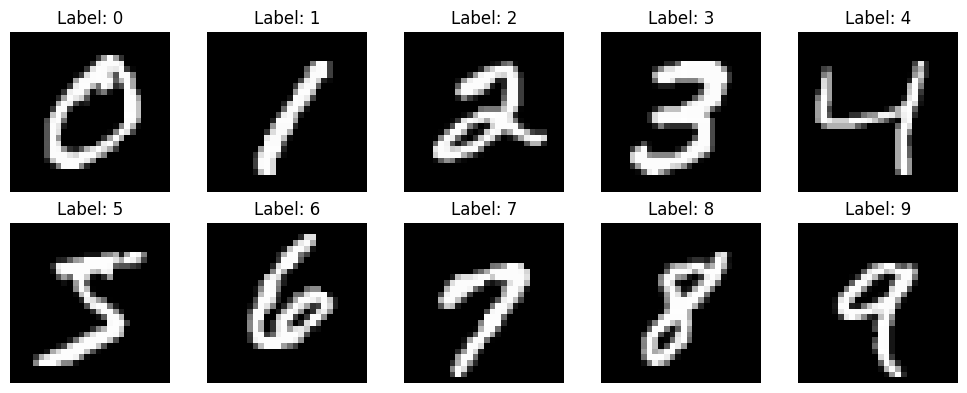

In [7]:
fig, axes = plt.subplots(2, 5, figsize=(10, 4))
for digit in range(10):
    row = con.execute(f"SELECT * FROM mnist WHERE label={digit} AND split='train' LIMIT 1").fetchone()
    pixels = np.array(row[:784]).reshape(28, 28)
    ax = axes[digit // 5, digit % 5]
    ax.imshow(pixels, cmap='gray')
    ax.set_title(f'Label: {digit}')
    ax.axis('off')
plt.tight_layout()
plt.show()

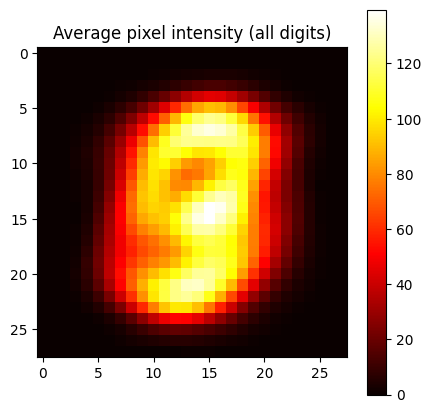

In [8]:
# Pixel intensity heatmap averaged across all training images
avg_pixels = con.execute("""
    SELECT {} FROM mnist WHERE split='train'
""".format(', '.join(f'AVG(px{i}) as px{i}' for i in range(784)))).fetchone()

plt.figure(figsize=(5, 5))
plt.imshow(np.array(avg_pixels).reshape(28, 28), cmap='hot')
plt.title('Average pixel intensity (all digits)')
plt.colorbar()
plt.show()

In [9]:
con.close()
print('DuckDB connection closed. Database saved at:', db_path)

DuckDB connection closed. Database saved at: ..\data\mnist.duckdb
